# Record Pairs: Single-Image Tiled Inference

This notebook runs the stage-1 segmentation model on a **single image** from `record_pairs` using tile inference, merges tile predictions back to original image size, and overlays:
- GT annotation bboxes (`label_name=vehicle`)
- Predicted mask and predicted bboxes


In [28]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("notebook")
%matplotlib inline
from matplotlib.patches import Rectangle
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision
from torchvision.transforms import functional as TF

from train_stage1_seg import load_records, tile_origins, crop_with_pad
from eval_stage1_seg import Stage1SegNet, connected_components


In [29]:
# ---- Config ----
DATA_DIR = Path('/home/schelli/git/wtcv/data/record_pairs')
CHECKPOINT = Path('runs/20260213-144609-finetune/checkpoints/final.pt')
LABEL_NAME = 'vehicle'

# Set one explicit image path from data-dir records. If None, a random record is used.
IMAGE_PATH = None

TILE_SIZE = 224
TILE_STRIDE = 112
SEG_OUT_STRIDE = 4
PRED_THRESHOLD = 0.5

# Tile classifier gating (used only if checkpoint has tile cls head).
USE_TILE_CLS_GATING = True
TILE_CLS_THRESHOLD = 0.5
TILE_CLS_GATING_MODE = 'hard'  # 'hard' or 'multiply'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
print('data_dir:', DATA_DIR)
print('checkpoint:', CHECKPOINT)


device: cuda
data_dir: /home/schelli/git/wtcv/data/record_pairs
checkpoint: runs/20260213-144609-finetune/checkpoints/final.pt


In [30]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Missing data dir: {DATA_DIR}')
if not CHECKPOINT.exists():
    raise FileNotFoundError(f'Missing checkpoint: {CHECKPOINT}')

records = load_records(DATA_DIR, LABEL_NAME, min_poly_points=3)
if not records:
    raise RuntimeError('No records loaded. Check DATA_DIR/LABEL_NAME.')

if IMAGE_PATH is None:
    idx = np.random.choice(len(records))
    rec = records[idx]
else:
    target = str(Path(IMAGE_PATH).resolve())
    rec = None
    for r in records:
        if str(Path(r['image_path']).resolve()) == target:
            rec = r
            break
    if rec is None:
        raise ValueError(f'IMAGE_PATH not found in loaded records: {IMAGE_PATH}')

print('selected image:', rec['image_path'])
print('num objects:', len(rec['objects']))


selected image: /home/schelli/git/wtcv/data/record_pairs/000521.png
num objects: 1


In [31]:
# Load checkpoint first, then build model with matching config (learned vs anyup, head, tile cls)
try:
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
except Exception as e:
    warnings.warn(
        'weights_only=True failed; falling back to weights_only=False. Use trusted checkpoints only. '
        f'Error: {e}'
    )
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)

if isinstance(ckpt, dict):
    ckpt_cfg = ckpt.get('cfg', {}) or {}
else:
    ckpt_cfg = {}

fusion_channels = int(ckpt_cfg.get('fusion_channels', 256))
dino_upsampler_type = str(ckpt_cfg.get('dino_upsampler_type', 'learned'))
anyup_q_chunk_size = int(ckpt_cfg.get('anyup_q_chunk_size', 256))
head_type = str(ckpt_cfg.get('head_type', 'pointwise'))
use_tile_cls_head = bool(ckpt_cfg.get('use_tile_cls_head', False))

model = Stage1SegNet(
    channels=fusion_channels,
    trust_repo=True,
    dino_upsampler_type=dino_upsampler_type,
    anyup_q_chunk_size=anyup_q_chunk_size,
    head_type=head_type,
    use_tile_cls_head=use_tile_cls_head,
).to(DEVICE)

state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
model.load_state_dict(state, strict=True)
model.eval()

print('checkpoint loaded')
print('detected fusion_channels:', fusion_channels)
print('detected dino_upsampler_type:', dino_upsampler_type)
print('detected head_type:', head_type)
print('detected use_tile_cls_head:', use_tile_cls_head)
if dino_upsampler_type == 'anyup':
    print('detected anyup_q_chunk_size:', anyup_q_chunk_size)


/tmp/ipykernel_40823/344862756.py:5: UserWarning: weights_only=True failed; falling back to weights_only=False. Use trusted checkpoints only. Error: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pathlib._local.PosixPath was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pathlib._local.PosixPath])` or the `torch.serialization.safe_globals([pathlib._local.PosixPath])` context manage

checkpoint loaded
detected fusion_channels: 256
detected dino_upsampler_type: learned
detected head_type: dwsep
detected use_tile_cls_head: True


In [32]:
# Run tiled inference and merge in low-res grid space, optionally gated by tile cls head
def infer_segmentation_on_image_with_tile_cls(
    model,
    image_np,
    tile_size,
    stride,
    seg_out_stride,
    device,
    use_tile_cls_gating=False,
    tile_cls_threshold=0.5,
    tile_cls_mode='hard',
):
    model.eval()
    img = Image.fromarray(image_np).convert('RGB')
    W, H = img.size

    gh, gw = H // seg_out_stride, W // seg_out_stride
    accum = np.zeros((gh, gw), dtype=np.float32)
    count = np.zeros((gh, gw), dtype=np.float32)
    cls_accum = np.zeros((gh, gw), dtype=np.float32)

    norm = torchvision.transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

    tile_cls_probs = []
    tile_cls_used = False

    for x0, y0 in tile_origins(W, H, tile_size, stride):
        tile = crop_with_pad(img, x0, y0, tile_size)
        x = norm(TF.to_tensor(tile)).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)
            prob = torch.sigmoid(pred['seg_logit'])[0, 0].cpu().numpy()

            tile_cls_prob = 1.0
            if 'tile_logit' in pred:
                tile_cls_prob = float(torch.sigmoid(pred['tile_logit'])[0, 0].item())
                tile_cls_used = True
            tile_cls_probs.append(tile_cls_prob)

            if use_tile_cls_gating and tile_cls_used:
                if tile_cls_mode == 'hard':
                    if tile_cls_prob < tile_cls_threshold:
                        prob = np.zeros_like(prob, dtype=np.float32)
                elif tile_cls_mode == 'multiply':
                    prob = prob * float(tile_cls_prob)

        th, tw = prob.shape
        gx0, gy0 = x0 // seg_out_stride, y0 // seg_out_stride
        gx1, gy1 = min(gw, gx0 + tw), min(gh, gy0 + th)

        pw = gx1 - gx0
        ph = gy1 - gy0
        if pw <= 0 or ph <= 0:
            continue

        patch = prob[:ph, :pw]
        accum[gy0:gy1, gx0:gx1] += patch
        count[gy0:gy1, gx0:gx1] += 1.0
        cls_accum[gy0:gy1, gx0:gx1] += float(tile_cls_prob)

    merged_prob = np.divide(accum, np.maximum(count, 1e-6))
    merged_cls = np.divide(cls_accum, np.maximum(count, 1e-6))

    stats = {
        'tile_cls_used': tile_cls_used,
        'tile_cls_mean': float(np.mean(tile_cls_probs)) if len(tile_cls_probs) > 0 else float('nan'),
        'tile_cls_min': float(np.min(tile_cls_probs)) if len(tile_cls_probs) > 0 else float('nan'),
        'tile_cls_max': float(np.max(tile_cls_probs)) if len(tile_cls_probs) > 0 else float('nan'),
    }
    return merged_prob, merged_cls, stats


img_np = np.array(Image.open(rec['image_path']).convert('RGB'), dtype=np.uint8)
H, W = img_np.shape[:2]

prob_lr, cls_lr, cls_stats = infer_segmentation_on_image_with_tile_cls(
    model=model,
    image_np=img_np,
    tile_size=TILE_SIZE,
    stride=TILE_STRIDE,
    seg_out_stride=SEG_OUT_STRIDE,
    device=DEVICE,
    use_tile_cls_gating=USE_TILE_CLS_GATING,
    tile_cls_threshold=TILE_CLS_THRESHOLD,
    tile_cls_mode=TILE_CLS_GATING_MODE,
)
pred_lr = (prob_lr >= PRED_THRESHOLD).astype(np.uint8)

# Upsample merged prediction back to original image size
t_prob = torch.from_numpy(prob_lr).float().unsqueeze(0).unsqueeze(0)
prob_full = F.interpolate(t_prob, size=(H, W), mode='bilinear', align_corners=False)[0, 0].numpy()
pred_full = (prob_full >= PRED_THRESHOLD).astype(np.uint8)

t_cls = torch.from_numpy(cls_lr).float().unsqueeze(0).unsqueeze(0)
cls_full = F.interpolate(t_cls, size=(H, W), mode='bilinear', align_corners=False)[0, 0].numpy()

print('image size:', (W, H))
print('low-res map size:', prob_lr.shape[::-1], '(W,H)')
print('pred positive pixels (full):', int(pred_full.sum()))
print('tile_cls stats:', cls_stats)
if cls_stats['tile_cls_used']:
    print('tile cls gating:', {'enabled': USE_TILE_CLS_GATING, 'mode': TILE_CLS_GATING_MODE, 'threshold': TILE_CLS_THRESHOLD})
else:
    print('checkpoint has no tile cls head; gating ignored')


image size: (1280, 720)
low-res map size: (320, 180) (W,H)
pred positive pixels (full): 694
tile_cls stats: {'tile_cls_used': True, 'tile_cls_mean': 0.09998577441835807, 'tile_cls_min': 5.732113395051641e-11, 'tile_cls_max': 0.9943899512290955}
tile cls gating: {'enabled': True, 'mode': 'hard', 'threshold': 0.5}


In [33]:
def gt_boxes_from_record(record):
    boxes = []
    for obj in record['objects']:
        x0, y0, x1, y1 = obj['bbox_xyxy']
        boxes.append((float(x0), float(y0), float(x1), float(y1)))
    return boxes

def pred_boxes_from_lr_components(pred_lr_mask, seg_out_stride):
    boxes = []
    comps = connected_components(pred_lr_mask.astype(np.uint8))
    for c in comps:
        ys, xs = np.where(c > 0)
        if ys.size == 0:
            continue
        x0_lr, x1_lr = xs.min(), xs.max() + 1
        y0_lr, y1_lr = ys.min(), ys.max() + 1
        x0 = float(x0_lr * seg_out_stride)
        y0 = float(y0_lr * seg_out_stride)
        x1 = float(x1_lr * seg_out_stride)
        y1 = float(y1_lr * seg_out_stride)
        boxes.append((x0, y0, x1, y1))
    return boxes

gt_boxes = gt_boxes_from_record(rec)
pred_boxes = pred_boxes_from_lr_components(pred_lr, SEG_OUT_STRIDE)

print('gt boxes:', len(gt_boxes))
print('pred boxes:', len(pred_boxes))


gt boxes: 1
pred boxes: 3


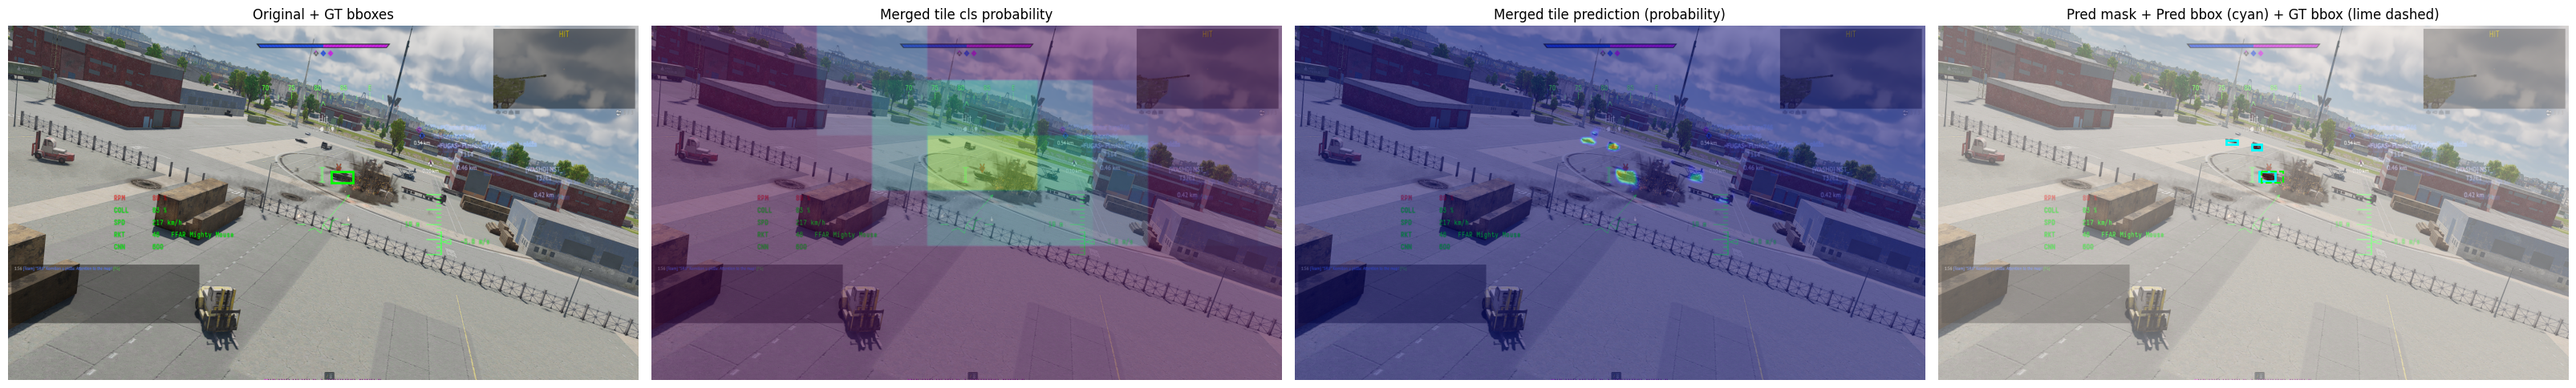

In [34]:
ncols = 4
fig, axes = plt.subplots(1, ncols, figsize=(32, 8), constrained_layout=True)

# Panel 1: original + GT bbox
axes[0].imshow(img_np)
axes[0].set_title('Original + GT bboxes')
for (x0, y0, x1, y1) in gt_boxes:
    axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=2))
axes[0].axis('off')

# Panel 2: merged tile-class map
axes[1].imshow(img_np)
axes[1].imshow(cls_full, cmap='viridis', alpha=0.45, vmin=0.0, vmax=1.0)
axes[1].set_title('Merged tile cls probability')
axes[1].axis('off')

# Panel 3: merged probability heatmap (full size)
axes[2].imshow(img_np)
axes[2].imshow(prob_full, cmap='jet', alpha=0.45, vmin=0.0, vmax=1.0)
axes[2].set_title('Merged tile prediction (probability)')
axes[2].axis('off')

# Panel 4: prediction mask + predicted bbox + GT bbox
axes[3].imshow(img_np)
axes[3].imshow(pred_full, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
for (x0, y0, x1, y1) in pred_boxes:
    axes[3].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='cyan', linewidth=2))
for (x0, y0, x1, y1) in gt_boxes:
    axes[3].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=1.5, linestyle='--'))
axes[3].set_title('Pred mask + Pred bbox (cyan) + GT bbox (lime dashed)')
axes[3].axis('off')

plt.show()


In [35]:
# Optional: quick overlap stats against GT union mask
gt_union = np.zeros((H, W), dtype=np.uint8)
for (x0, y0, x1, y1) in gt_boxes:
    x0i, y0i = max(0, int(np.floor(x0))), max(0, int(np.floor(y0)))
    x1i, y1i = min(W, int(np.ceil(x1))), min(H, int(np.ceil(y1)))
    if x1i > x0i and y1i > y0i:
        gt_union[y0i:y1i, x0i:x1i] = 1

inter = np.logical_and(pred_full > 0, gt_union > 0).sum()
union = np.logical_or(pred_full > 0, gt_union > 0).sum()
iou = float(inter / union) if union > 0 else 1.0
print({'pred_pixels': int(pred_full.sum()), 'gt_pixels': int(gt_union.sum()), 'bbox_union_iou': iou})


{'pred_pixels': 694, 'gt_pixels': 1058, 'bbox_union_iou': 0.3094170403587444}
